In [4]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [5]:
import cellina
cellina.__version__

'0.0.2'

In [6]:
import scanpy as sc
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys

sys.path.append('../scripts')

In [7]:
from train_loo import (
    preprocess_adata,
    split_indices,
    _load_model,
    DEFAULT_SEED,
    ADATA_ARGS,
    DEFAULT_LABELS_KEY,
    DEFAULT_DOMAINS_KEY,
    DEFAULT_BATCH_KEY,
)

from eval_loo import compute_correlations, get_edistance, mixing_index

from counterfactual_analysis import _normalize_counts

In [8]:
#lambdas = [1e-7, 1e-5, 1e-3, 0.01, 0.1, 0.5, 1]
lambdas = [0., 1e-5, 1e-3, 0.01, 0.1, 1, 5]
model_root = "/data2/a330d/data/ood/trained/tuning"
holdout_celltype = "Endothelial"
batch_size = 4096

In [9]:
slide_id = "crc_232"
adata_path = f"/data2/a330d/datasets/crc/raw_zenodo/{slide_id}.h5ad"
adata = sc.read(adata_path)

In [10]:
n_top_genes = ADATA_ARGS.get('n_top_genes', 2000)
n_neighbors = ADATA_ARGS.get('n_neighbors', 50)
labels_key = ADATA_ARGS.get('labels_key', DEFAULT_LABELS_KEY)
domains_key = ADATA_ARGS.get('domains_key', DEFAULT_DOMAINS_KEY)
batch_key = ADATA_ARGS.get('batch_key', DEFAULT_BATCH_KEY)

adata = preprocess_adata(adata, n_top_genes=n_top_genes, n_neighbors=n_neighbors)

# create splits so train_model can use them
train_idx, val_idx, test_idx = split_indices(adata, holdout_celltype, labels_key=labels_key, domains_key=domains_key, seed=DEFAULT_SEED)
splits = (train_idx, val_idx, test_idx)

sid = os.path.splitext(os.path.basename(adata_path))[0]

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [11]:
# Inference
adata_ct = adata[adata.obs[labels_key] == holdout_celltype]

# Counterfactuals
is_tumor_region = adata_ct.obs[domains_key].astype(str).str.contains('CRC', regex=True)
mask_target = is_tumor_region & (adata_ct.obs[labels_key].astype(str) == holdout_celltype)
idx_target = np.where(mask_target.values)[0]
mask_control = (~adata_ct.obs['is_holdout']) & (adata_ct.obs[labels_key] == holdout_celltype)
idx_control = np.where(mask_control.values)[0]

In [12]:
results = []

for lam in tqdm(lambdas, desc='Lambda value'):
    model_dir = f"{model_root}/{sid}/{holdout_celltype}/cellina_{lam}"  
    model = _load_model(model_dir, 
                        model_class='cellina',
                        adata=adata,
                        splits=splits
                        )
     
    # Reconstructions
    library_size = 'latent'
    adata_ct.uns['recon_x'] = model.get_normalized_expression(adata_ct, library_size=library_size, batch_size=batch_size)
    adata_ct.uns['latents'] = model.get_latent_representation(adata_ct, batch_size=batch_size)

    # Counterfactuals
    args_gex = {    
        "indices": idx_control,
        "neighbour_indices": idx_target,
        "batch_size": batch_size,
        "seed": 0,
    }
    args_gex["adata"] = adata_ct
    cf_counts = model.get_counterfactual_expression(**args_gex)
    #adata_ct.uns['counterfactual_x'] = _normalize_counts(cf_counts, eps=1e-8, scale=1e4)
    adata_ct.uns['counterfactual_x'] = cf_counts    
    args_latents = args_gex.copy()
    adata_ct.uns['counterfactual_latents'] = model.get_counterfactual_latents(**args_latents)

    # Run evaluations
    pear, spear, prec, top_features = compute_correlations(adata_ct, holdout_celltype, use_recon=False)

    # e-distance (cell level using counts)
    edist_cells = get_edistance(adata_ct, n_subsample=200, n_iter=5, use_cf=True, deg=top_features, use_latents=False)

    # e-distance (latents)
    edist_latents = get_edistance(adata_ct, n_subsample=200, use_latents=True)

    # local e-distance
    edist_local = get_edistance(adata_ct, n_subsample=200, use_cf=True, deg=top_features, local=True)

    # mixing index
    mix_idx = mixing_index(adata_ct, n_clusters=2, n_pcs=50, random_state=0)

    # compute MSE/RMSE between mean observed target counts and mean cf counts
    # observed target
    # MSE between recon and observed
    X = np.array(adata_ct.layers['counts'].todense()[idx_target])
    Y = np.array(adata_ct.uns['recon_x'][idx_target])

    X = _normalize_counts(X)
    Y = _normalize_counts(Y)

    mse = np.mean((X - Y) ** 2)
    rmse = np.sqrt(mse)

    results.append({
        'lambda': lam,
        'pearson': pear,
        'spearman': spear,
        'precision_at_k': prec,
        'edistance_cells': edist_cells,
        'edistance_latents': edist_latents,
        'edistance_local': edist_local,
        'mixing_index': mix_idx,
        'mse': mse,
        'rmse': rmse,
    })

Lambda value:   0%|          | 0/7 [00:00<?, ?it/s]

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/ood/trained/tuning/crc_232/Endothelial/cellina_0.0/model.pt already downloaded     


/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized                                                           
cellina loaded model from /data2/a330d/data/ood/trained/tuning/crc_232/Endothelial/cellina_0.0
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


Using counterfactual latents for e-distance computation


Lambda value: 100%|██████████| 7/7 [00:27<00:00,  3.93s/it]


In [13]:
df = pd.DataFrame(results)

In [14]:
group1 = ["pearson", "spearman", "precision_at_k"]
group2 = ["edistance_cells", "edistance_local"]
group3 = ["mse", "rmse"]

groups = [group1, group2, group3]
titles = ["Correlation & Mixing", "E-distances", "Error metrics"]

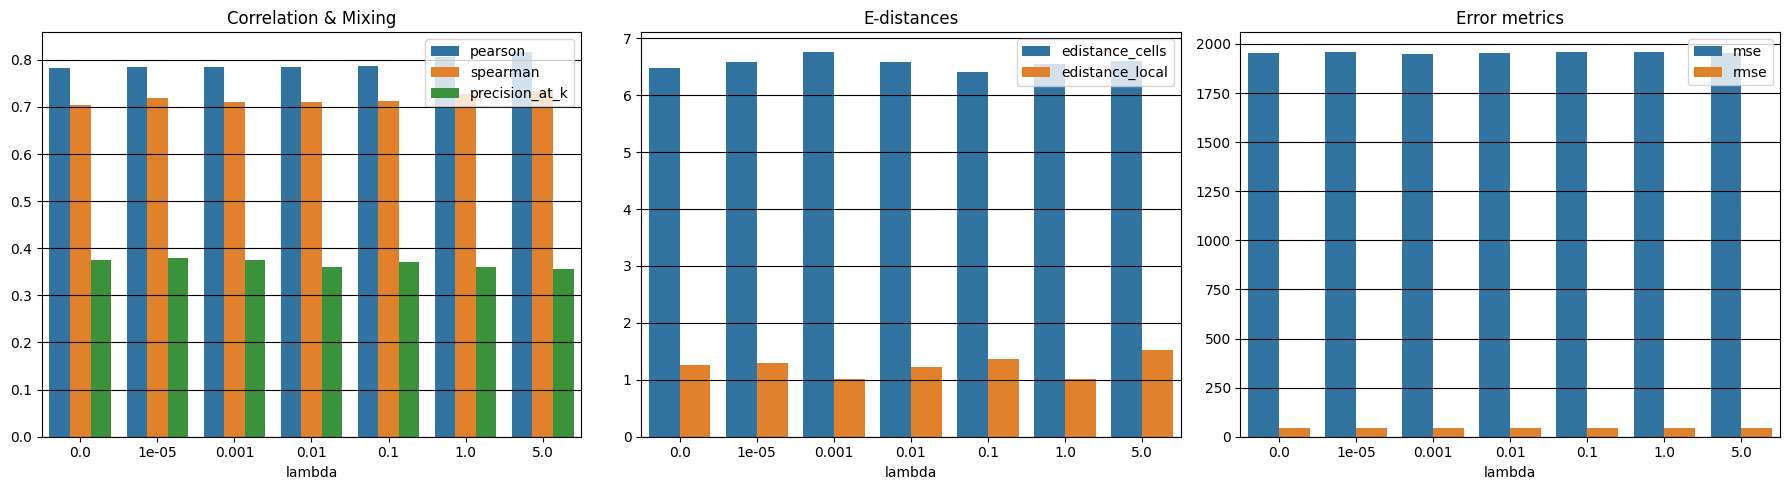

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)

for ax, metrics, title in zip(axes, groups, titles):
    sub = df[["lambda"] + metrics].melt(
        id_vars="lambda",
        var_name="metric",
        value_name="value"
    )

    sns.barplot(
        data=sub,
        x="lambda",
        y="value",
        hue="metric",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("lambda")
    ax.set_ylabel("")
    ax.legend(title="")

    ax.yaxis.grid(True, color='black')
    ax.xaxis.grid(False)
plt.tight_layout()
plt.show()

In [9]:
import cpa
adata.obs['dose'] = 1.0 # NOTE: dummy dose for compatibility with CPA model
adata.obs['data_split'] = 'train'
adata.obs.iloc[splits[1], adata.obs.columns.get_loc('data_split')] = 'valid'
adata.obs.iloc[splits[2], adata.obs.columns.get_loc('data_split')] = 'test'
save_dir = f"/data2/a330d/data/ood/trained/{slide_id}/{holdout_celltype}/cpa"
model = cpa.CPA.load(dir_path=save_dir,
                adata=adata,
                use_gpu=True)

INFO     File /data2/a330d/data/ood/trained/crc_232/Endothelial/cpa/model.pt already downloaded                    


100%|██████████| 111989/111989 [00:00<00:00, 1590876.77it/s]
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Global seed set to 6977


In [19]:
model.predict(adata_ct, batch_size=batch_size)
adata_ct.uns['recon_x'] = adata_ct.obsm["CPA_pred"]
latents = model.get_latent_representation(adata=adata_ct, batch_size=batch_size)
adata_ct.uns['latents'] = latents["latent_after"].X

100%|██████████| 2/2 [00:00<00:00, 14.01it/s]


In [20]:
from cpa._utils import CPA_REGISTRY_KEYS
# Subset adata - this is how CPA does counterfactuals
adata_ctrl = adata_ct[idx_control].copy()
perturbation_idx = model.pert_encoder['CRC']
# Change perturbation label ctrl -> stimulated
adata_ctrl.obsm['perts'][:, 0] = perturbation_idx
# Mark as non-control (control flag = 0)
adata_ctrl.obs[CPA_REGISTRY_KEYS.CONTROL_KEY] = 0

# Create counterfactuals - normalizing counts at the end before saving, so set False here
model.predict(adata_ctrl, batch_size=batch_size)
adata_ct.uns['counterfactual_x'] = adata_ctrl.obsm["CPA_pred"]
latents = model.get_latent_representation(adata=adata_ctrl, batch_size=batch_size)
adata_ct.uns['counterfactual_latents'] = latents["latent_after"].X

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


100%|██████████| 1/1 [00:00<00:00, 86.64it/s]


In [21]:
# Run evaluations
pear, spear, prec, top_features = compute_correlations(adata_ct, holdout_celltype, use_recon=False)

# e-distance (cell level using counts)
edist_cells = get_edistance(adata_ct, n_subsample=200, n_iter=5, use_cf=True, deg=top_features, use_latents=False)

# e-distance (latents)
edist_latents = get_edistance(adata_ct, n_subsample=500, use_latents=True)

# local e-distance
edist_local = get_edistance(adata_ct, n_subsample=500, use_cf=True, deg=top_features, local=True)

# mixing index
mix_idx = mixing_index(adata_ct, n_clusters=2, n_pcs=50, random_state=0)

Using counterfactual latents for e-distance computation


In [22]:
pear, spear, prec

(0.7345458279512511, 0.6999759903961584, 0.12)

In [24]:
edist_cells, edist_latents, edist_local, mix_idx

(3.583278933569575, 14.30374801158905, 2.4691225302506967, 0.9477567211579403)